<a href="https://colab.research.google.com/github/tomz3302/Egyptian-Currency-Classifier/blob/main/Egyptian_Currency_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Egyptian Currency Classification Project
**Team Members:** Omar Dardir & Roger Sherif
**Dataset:** [Egyptian New Currency 2023](https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023)

### Environment Setup
Run this cell to install dependencies and import libraries.

In [5]:
!pip install opendatasets
import os
from google.colab import drive
import opendatasets as od
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import joblib # For saving the model later
import numpy as np
import cv2
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from PIL import Image
import shutil

# Define where your images are based on your screenshot
base_dir = './egyptian-new-currency-2023/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Common settings
IMG_SIZE = (224, 224) # Standard size for most models
BATCH_SIZE = 32

## Data Acquisition
In this section, we mount our shared Google Drive and download the currency images using the Kaggle API.

In [2]:

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project'

# This makes all your relative paths work from inside this folder
%cd {project_path}

# Verify where you are
!pwd

Mounted at /content/drive
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project


In [ ]:
dataset_folder = './egyptian-new-currency-2023'

if not os.path.exists(dataset_folder):
    print("Downloading dataset...")
    od.download("https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023")
else:
    print("Dataset already present in this session.")

Dataset already present in this session.


##Data Cleaning

In [6]:
def tf_aggressive_clean(directory):
    print(f"🔎 Scanning {directory} with TensorFlow decoder...")
    removed_count = 0
    scanned_count = 0

    # Walk through all folders
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            scanned_count += 1

            # 1. Delete "Ghost" files (common Mac/Windows transfer artifacts)
            if file.startswith("._") or file == ".DS_Store":
                try:
                    os.remove(file_path)
                    removed_count += 1
                    print(f"❌ Removed system file: {file}")
                except:
                    pass
                continue

            # 2. Ask TensorFlow to decode it
            try:
                # Read the raw bytes
                file_contents = tf.io.read_file(file_path)

                # Try to decode (this mimics what dataset_from_directory does)
                # expand_animations=False fixes issues with some BMP/GIFs disguised as JPGs
                img = tf.io.decode_image(file_contents, channels=3, expand_animations=False)

                # Force execution to catch corrupt data
                # (TensorFlow is lazy, so we must inspect the shape to trigger the decode)
                if img.shape is None or img.shape[0] == 0:
                    raise ValueError("Empty image")

            except Exception as e:
                # If TF failed, delete the file
                print(f"🗑️ Deleting corrupt file: {file} | Error: {e}")
                try:
                    os.remove(file_path)
                    removed_count += 1
                except:
                    print(f"Could not delete {file_path}")

    print(f"✅ Scan complete. Scanned {scanned_count} files. Removed {removed_count} bad files.")

# Update these paths to match your Colab folder structure exactly
base_dir = './egyptian-new-currency-2023/dataset'

tf_aggressive_clean(os.path.join(base_dir, 'train'))
tf_aggressive_clean(os.path.join(base_dir, 'valid'))
tf_aggressive_clean(os.path.join(base_dir, 'test'))

🔎 Scanning ./egyptian-new-currency-2023/dataset/train with TensorFlow decoder...
🗑️ Deleting corrupt file: 100.10.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 100.54.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.43.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.45.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting c

## Preprocessing
Before training, we need to:
1. Resize images to a uniform shape.
2. Normalize pixel values (0 to 1).
3. Split the data into Training and Validation sets.

In [7]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
    #This gives us numbers 0, 1, 2... for each class (example
    #folder 5: 0, folder 10 (new): 1 etc...)
)
class_names = train_ds.class_names
print(f"Captured classes: {class_names}")

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)
class_names = val_ds.class_names
print(f"Captured classes: {class_names}")

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)
class_names = test_ds.class_names

# Normalize the pixels
# Each pixel has a value from 0 to 255 (0 is black, 255 is white)
# This turns pixel values like 255 into 1.0, making it easier for the model to learn color patterns.

#X is the images, Y is the labels
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 2631 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 756 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 287 files belonging to 9 classes.


## Data Exploration
Just a quick look at a few sample images to make sure our labels (5, 10, 20 EGP, etc.) match the pictures.

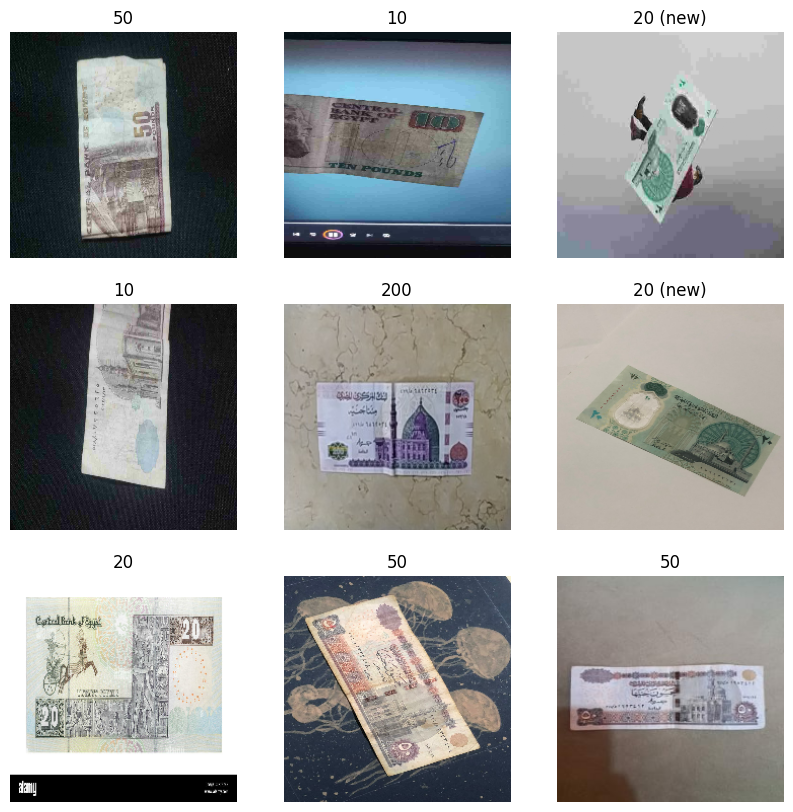

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        # We use the 'class_names' list we saved in the previous cell
        plt.title(class_names[labels[i]])
        plt.axis("off")

##Feature Extraction (HSV Histograms)

In [9]:
def extract_hsv_features(dataset):
    features = []
    labels = []

    print("Extracting HSV features...")
    for images, batch_labels in dataset:
        for img, label in zip(images, batch_labels):
            # 1. Convert tensor to numpy and rescale to 0-255
            img_np = (img.numpy() * 255).astype('uint8')

            # 2. Convert from RGB to HSV
            # Note: TensorFlow loads images as RGB
            img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

            # 3. Calculate Histograms for H, S, and V
            # Hue has a range of 0-180 in OpenCV
            h_hist = cv2.calcHist([img_hsv], [0], None, [32], [0, 180])
            s_hist = cv2.calcHist([img_hsv], [1], None, [32], [0, 256])
            v_hist = cv2.calcHist([img_hsv], [2], None, [32], [0, 256])

            # 4. Normalize and flatten
            combined_hist = np.concatenate([h_hist, s_hist, v_hist]).flatten()
            combined_hist = combined_hist / np.sum(combined_hist) # Normalize sum to 1

            features.append(combined_hist)
            labels.append(label.numpy())

    return np.array(features), np.array(labels)

# Extract features from your existing tf.data.Dataset objects
X_train, y_train = extract_hsv_features(train_ds)
X_val, y_val = extract_hsv_features(val_ds)
X_test, y_test = extract_hsv_features(test_ds)

print(f"Feature extraction complete. Training shape: {X_train.shape}")

Extracting HSV features...
Extracting HSV features...
Extracting HSV features...
Feature extraction complete. Training shape: (2631, 96)


## Model Training

In [10]:
# Initialize the Random Forest
# n_estimators=200 means we are using 200 virtual "decision trees"
model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)

print("Training the Random Forest model...")
model.fit(X_train, y_train)

print("Model training finished!")

Training the Random Forest model...
Model training finished!


# Evaluation
Testing the model on images it has never seen before to calculate the final accuracy.

Overall Accuracy: 86.51%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.95      0.95        20
          10       0.82      0.82      0.82        80
    10 (new)       0.90      0.90      0.90       130
         100       0.91      0.72      0.81        80
          20       0.82      0.85      0.83        80
    20 (new)       0.97      0.93      0.95       130
         200       0.87      0.92      0.90        79
           5       0.80      0.91      0.85        80
          50       0.75      0.77      0.76        77

    accuracy                           0.87       756
   macro avg       0.87      0.86      0.86       756
weighted avg       0.87      0.87      0.86       756



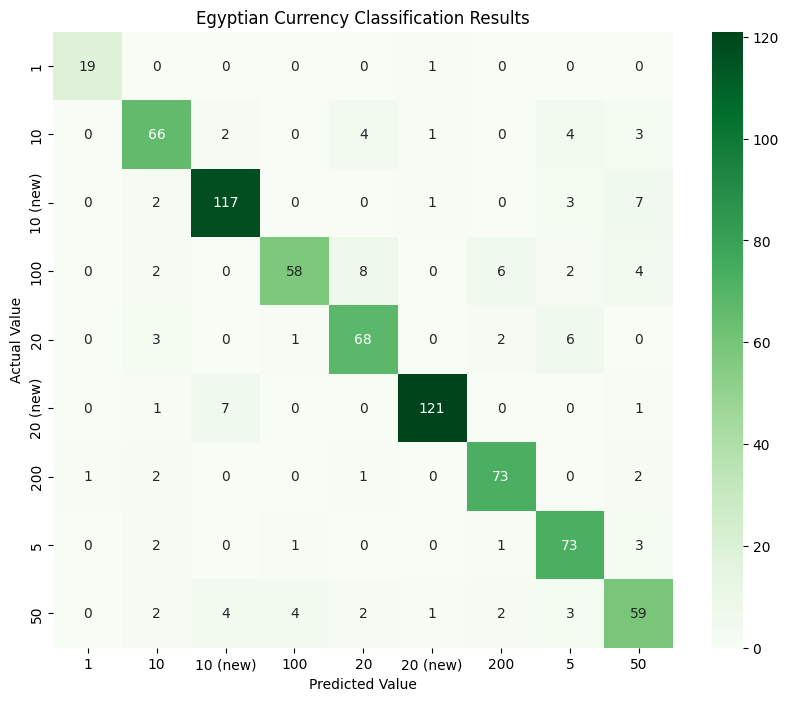

In [11]:
# Make predictions
y_pred = model.predict(X_val)

# Print Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# Detailed Report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# Visualize with a Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Egyptian Currency Classification Results')
plt.show()